# why are the 2 cor runs different

In [1]:
import numpy as np 
import sys
import pandas as pd
import datetime as datetime    
import xarray as xr 
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates 
import matplotlib as mpl
import re 
from scipy import signal #for filtering
import cmocean
import matplotlib.dates as mdates
print("Modules imported")

Modules imported


In [4]:
file27='/expanse/lustre/scratch/jisrael/temp_project/run_schism/run_27/station_files/staout_6_filt.csv'
filenew='/expanse/lustre/scratch/jisrael/temp_project/run_schism/savio_output/run_30cor/staout_6_filt.csv' #596 stations
fileold='/expanse/lustre/scratch/jisrael/temp_project/run_schism/run_29/outputs_bc_all/staout_6_filt.csv' #408 stations

In [5]:
#load the filtered station data
dtformat = '%Y-%m-%d %H:%M:%S'
run27=pd.read_csv(file27)
run27['datetime']=pd.to_datetime(run27['time'],format=dtformat)
run27.set_index("datetime",inplace=True)
runnew=pd.read_csv(filenew)
runnew['datetime']=pd.to_datetime(runnew['time'],format=dtformat)
runnew.set_index("datetime",inplace=True)
runold=pd.read_csv(fileold)
runold['datetime']=pd.to_datetime(runold['time'],format=dtformat)
runold.set_index("datetime",inplace=True)

/scratch/jisrael/job_50642378/ipykernel_3494272/2916038423.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  run27['datetime']=pd.to_datetime(run27['time'],format=dtformat)
/scratch/jisrael/job_50642378/ipykernel_3494272/2916038423.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  runnew['datetime']=pd.to_datetime(runnew['time'],format=dtformat)
/scratch/jisrael/job_50642378/ipykernel_3494272/2916038423.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times

(0, 0)
(0, 1)
(1, 0)
(1, 1)
(2, 0)
(2, 1)


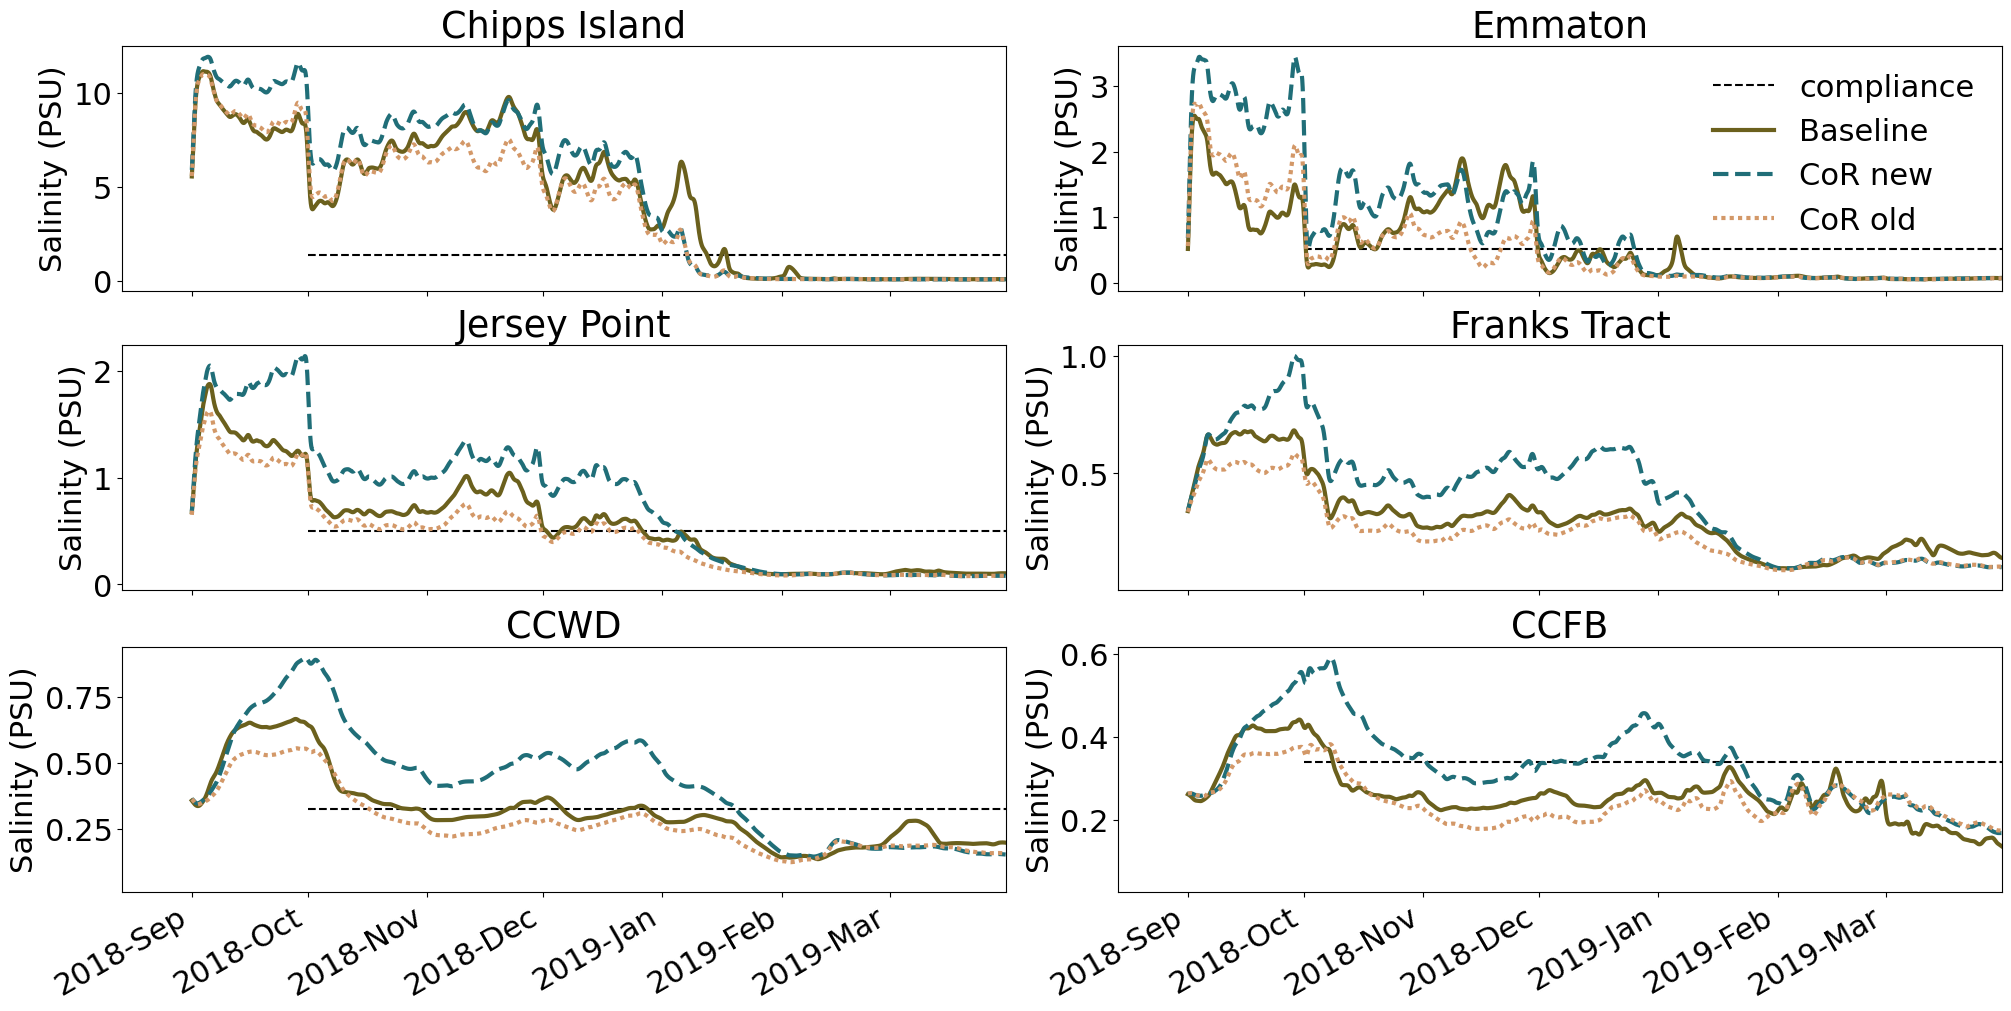

In [7]:
#station_indices=[226,22,12,168,6,203] 
#from Lily:
station_indices=[23,9,22,203,105,60]
fig, ax = plt.subplots(3,2,figsize=(20,10),sharex=True,layout='constrained',label='compliance')
mpl.rcParams.update({'font.size': 22})
# ax.grid(alpha=0.5)
for idx in station_indices:
    if idx == 23:
        s=(0,0)
        tstring='Chipps Island'
        #ax[s].hlines(y=1.3775, xmin=pd.to_datetime("2019-2-1"), xmax=pd.to_datetime("2019-6-1"),color='k',linestyle='--',label='compliance')
        ax[s].hlines(y=1.3775, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-6-1"),color='k',linestyle='--',label='compliance')
    if idx == 9:
        s=(0,1)
        tstring='Emmaton'
        #ax[s].hlines(y=0.5055, xmin=pd.to_datetime("2019-4-1"), xmax=pd.to_datetime("2019-8-15"),color='k',linestyle='--',label='compliance')
        ax[s].hlines(y=0.5055, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-8-15"),color='k',linestyle='--',label='compliance')
    if idx == 22:
        s=(1,0)
        tstring='Jersey Point'
        #ax[s].hlines(y=0.5055, xmin=pd.to_datetime("2019-4-1"), xmax=pd.to_datetime("2019-8-15"),color='k',linestyle='--',label='compliance')
        ax[s].hlines(y=0.5055, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-8-15"),color='k',linestyle='--',label='compliance')
    if idx == 203:
        s=(1,1)
        tstring='Franks Tract'
    if idx == 105:
        s=(2,0)
        tstring='CCWD'
        ax[s].hlines(y=0.3255, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-10-1"),color='k',linestyle='--',label='compliance')
    if idx == 60:
        s=(2,1)
        tstring='CCFB'
        ax[s].hlines(y=0.3387, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-10-1"),color='k',linestyle='--',label='compliance')
    
    print(s)
    values1 = run27[str(idx)]
    values2 = runnew[str(idx)]
    values3 = runold[str(idx)]
       
    ax[s].plot(values1, label = 'Baseline', linewidth=3, alpha =1, color=cmocean.cm.tarn(1/6))
    ax[s].plot(values2, label = 'CoR new', linewidth=3, alpha =1,linestyle='--', color=cmocean.cm.tarn(10/12))
    ax[s].plot(values3, label = 'CoR old', linewidth=3, alpha =1,linestyle=(0,(1,1)), color=cmocean.cm.tarn(2/6))
    #ax[s].set_title(stations[idx-1]) #this list is zero indexed
    ax[s].set_title(tstring)
    #ax[s].set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))
    ax[s].set_xlim(pd.to_datetime("2018-8-14"),pd.to_datetime("2019-3-31"))
    ax[s].set_ylabel('Salinity (PSU)')
    # Rotates and right-aligns the x labels so they don't crowd each other.

    
#ax.plot(data1.time,np.ones_like(values1)*std,linewidth=2, alpha =0.7,linestyle='--',color='k',label='Compliance')

#leg = ax.legend()
#print(ax)
#ax.set_xlim(data1.time.iloc[52000], data3.time.iloc[-1]) #July 1 to end
# ax.grid(which='major', color='b', linestyle='-')
#ax.set_title("Salinity from baroclinic run")
#ax[0,1].xaxis.set_major_formatter(mdates.DateFormatter('%b-%d-%Y'))
ax[0,1].legend(frameon=False)
ax[2,0].xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax[2,0].xaxis.get_major_locator()))
ax[2,0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))
    # Rotates and right-aligns the x labels so they don't crowd each other.
for label in ax[2,0].get_xticklabels(which='major'):
    label.set(rotation=30, horizontalalignment='right')
ax[2,1].xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax[2,1].xaxis.get_major_locator()))
ax[2,1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))
    # Rotates and right-aligns the x labels so they don't crowd each other.
for label in ax[2,1].get_xticklabels(which='major'):
    label.set(rotation=30, horizontalalignment='right')

plt.show()
#fig.savefig('./figures/2026_06_06_six_stations_timeseries_legend_2_endmarch.png')

# Do the input files vary in September?

In [8]:
# load the flux time series for each scenario
base=pd.read_csv('/home/jisrael/BayDeltaSCHISM/data/time_history/flux.th',sep=r'\s+',parse_dates=["datetime"],dtype=np.float32).set_index(["datetime"])
#dcp=pd.read_csv('/home/jisrael/Savio_scratch_back_up/scenario_files/DCP/data/time_history/flux_dcp_fixinterp_20260516.th.ported',sep=r'\s+',parse_dates=["datetime"],dtype=np.float32).set_index(["datetime"])
cor1=pd.read_csv('/home/jisrael/Savio_scratch_back_up/scenario_files/reserves/data/time_history/flux_cor_fixinterp_20260516.th.ported',sep=r'\s+',parse_dates=["datetime"],dtype=np.float32).set_index(["datetime"])
cor2=pd.read_csv('/home/jisrael/Savio_scratch_back_up/scenario_files/reserves/data/time_history/flux_s0044.th.ported',sep=r'\s+',parse_dates=["datetime"],dtype=np.float32).set_index(["datetime"])


In [9]:
# resample to be daily
base=base.resample('D').mean()
cor1=cor1.resample('D').mean()
cor2=cor2.resample('D').mean()

In [10]:
# calculate total inflows and exports
base['exports']=base.swp+base.cvp+base.ccc_rock+base.northbay+base.ccc_victoria+base.ccc_old

cor1['exports']=cor1.swp+cor1.cvp+cor1.ccc_rock+cor1.northbay+cor1.ccc_victoria+cor1.ccc_old
cor2['exports']=cor2.swp+cor1.cvp+cor2.ccc_rock+cor2.northbay+cor2.ccc_victoria+cor2.ccc_old

base['s_exports']=base.swp+base.cvp
cor1['s_exports']=cor1.swp+cor1.cvp
cor2['s_exports']=cor2.swp+cor2.cvp


base['inf']=(base['sac']+base['east']+base['sjr']+base['yolo']+base['calaveras']+base['yolo_toedrain']+base['coyote']+base['napa']+base['american'])*-1
cor1['inf']=(cor1['sac']+cor1['east']+cor1['sjr']+cor1['yolo']+cor1['calaveras']+cor1['yolo_toedrain']+cor1['coyote']+cor1['napa']+cor1['american'])*-1
cor2['inf']=(cor2['sac']+cor2['east']+cor2['sjr']+cor2['yolo']+cor2['calaveras']+cor2['yolo_toedrain']+cor2['coyote']+cor2['napa']+cor2['american'])*-1

base['net']=base.inf-base.exports
cor1['net']=cor1.inf-cor1.exports
cor2['net']=cor2.inf-cor2.exports

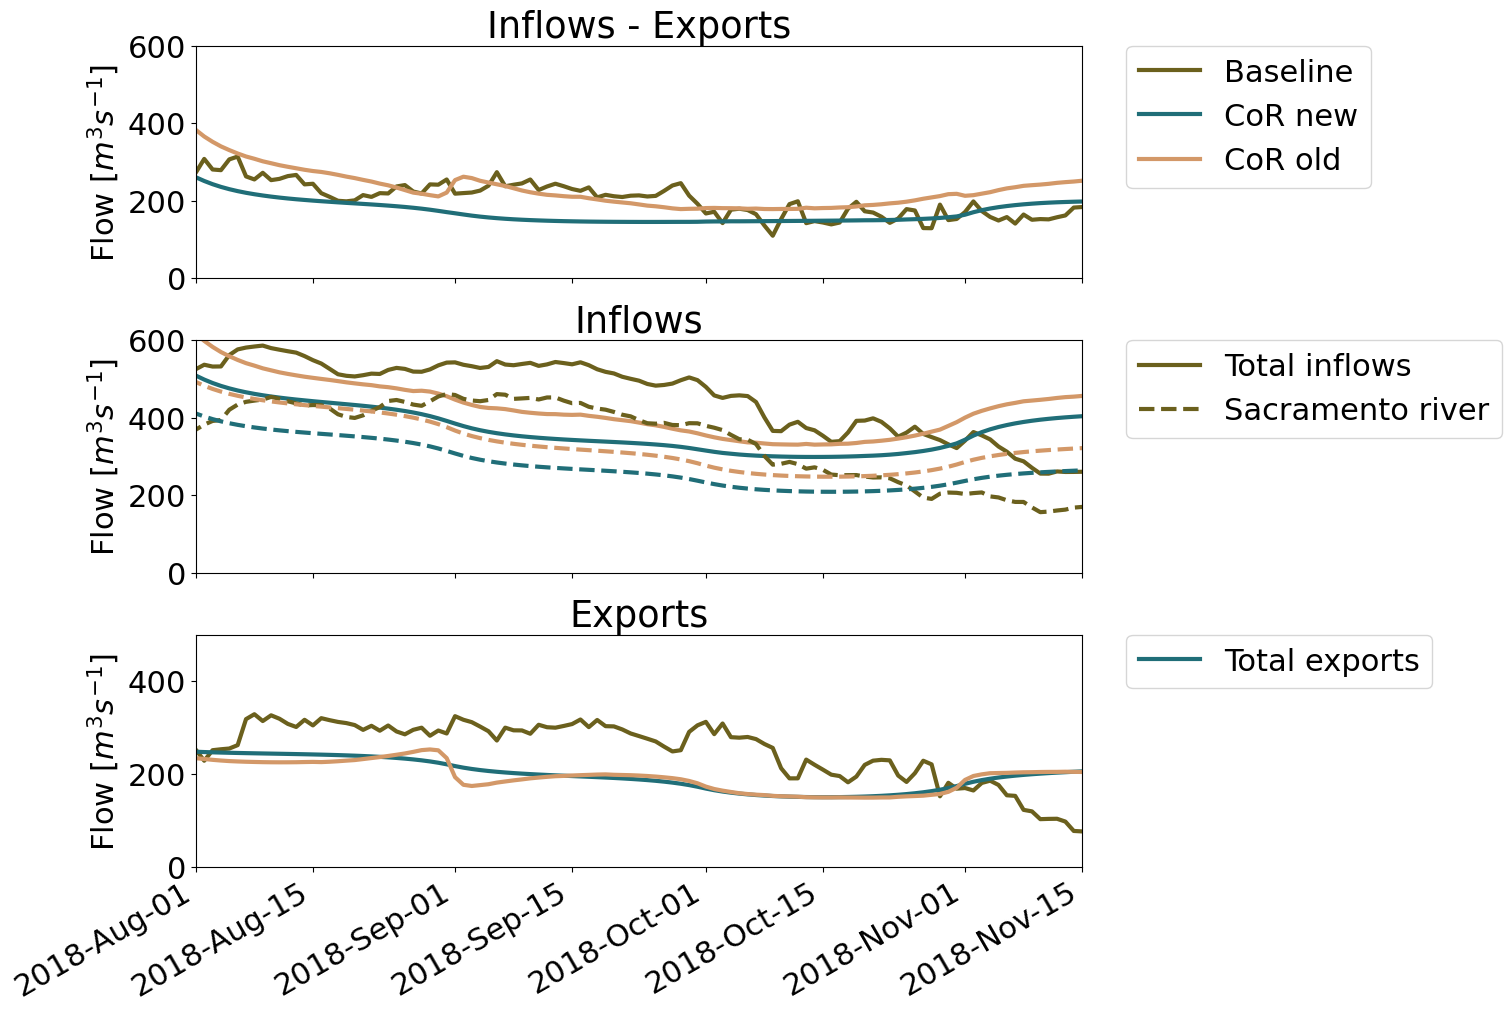

In [13]:
# make stacked plots 
fig, ax = plt.subplots(3,figsize=(15,10),sharex=True,layout='constrained')
mpl.rcParams.update({'font.size': 22})

ax[0].plot(base.net,label='Baseline', linewidth=3,color=cmocean.cm.tarn(1/6))
ax[0].plot(cor1.net,label='CoR new', linewidth=3,color=cmocean.cm.tarn(10/12))
ax[0].plot(cor2.net,label='CoR old', linewidth=3,color=cmocean.cm.tarn(2/6))
ax[0].set_title('Inflows - Exports')
ax[0].set_ylabel(r'Flow [$m^3 s^{-1}$]')
ax[0].set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))
ax[0].set_ylim(0,600)
ax[0].legend(bbox_to_anchor=(1.05, 1),
                         loc='upper left', borderaxespad=0.)

ax[1].plot(base.inf, linewidth=3,label='Total inflows',color=cmocean.cm.tarn(1/6))
ax[1].plot(cor1.inf, linewidth=3,color=cmocean.cm.tarn(10/12))
ax[1].plot(cor2.inf, linewidth=3,color=cmocean.cm.tarn(2/6))

ax[1].plot(base.sac*-1, linewidth=3,label='Sacramento river',color=cmocean.cm.tarn(1/6),linestyle='--')
ax[1].plot(cor1.sac*-1, linewidth=3,color=cmocean.cm.tarn(10/12),linestyle='--')
ax[1].plot(cor2.sac*-1, linewidth=3,color=cmocean.cm.tarn(2/6),linestyle='--')

# ax[1].plot(base.sjr*-1, linewidth=3,label='San Joaquin river',color=cmocean.cm.tarn(1/6),linestyle=(0,(1,1)))
# ax[1].plot(cor1.sjr*-1, linewidth=3,color=cmocean.cm.tarn(10/12),linestyle=(0,(1,1)))
# ax[1].plot(cor2.sjr*-1, linewidth=3,color=cmocean.cm.tarn(2/6),linestyle=(0,(1,1)))

# ax[1].plot(base.yolo*-1, linewidth=3,label='Yolo bypass',color=cmocean.cm.tarn(1/6),linestyle=(0,(1,1)))
# ax[1].plot(cor1.yolo*-1, linewidth=3,color=cmocean.cm.tarn(10/12),linestyle=(0,(1,1)))
# # ax[1].plot(cor2.yolo*-1, linewidth=3,color=cmocean.cm.tarn(2/6),linestyle=(0,(1,1)))

ax[1].legend(bbox_to_anchor=(1.05, 1),
                         loc='upper left', borderaxespad=0.)
ax[1].set_title('Inflows')
ax[1].set_ylabel(r'Flow [$m^3 s^{-1}$]')
ax[1].set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))
ax[1].set_ylim(0,600)

ax[2].plot(base.exports, linewidth=3,color=cmocean.cm.tarn(1/6))
ax[2].plot(cor1.exports, linewidth=3,color=cmocean.cm.tarn(10/12),label='Total exports')
ax[2].plot(cor2.exports, linewidth=3,color=cmocean.cm.tarn(2/6))

#ax[2].plot(tunnel, linewidth=3,linestyle=(0,(1,1)),label='N. Delta exports',color=cmocean.cm.tarn(10/12))

# ax[2].plot(base.s_exports, linewidth=3,color=cmocean.cm.tarn(1/6),linestyle='--')
# ax[2].plot(cor1.s_exports, linewidth=3,color=cmocean.cm.tarn(10/12),linestyle='--',label='S. Delta exports')
# ax[2].plot(cor2.s_exports, linewidth=3,color=cmocean.cm.tarn(2/6),linestyle='--')

ax[2].legend(bbox_to_anchor=(1.05, 1),
                         loc='upper left', borderaxespad=0.)
ax[2].set_title('Exports')
ax[2].set_ylabel(r'Flow [$m^3 s^{-1}$]')
ax[2].set_xlim(pd.to_datetime("2018-8-1"),pd.to_datetime("2018-11-15"))
ax[2].set_ylim(0,500)

ax[2].xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax[2].xaxis.get_major_locator()))
ax[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b-%d'))
    # Rotates and right-aligns the x labels so they don't crowd each other.
for label in ax[2].get_xticklabels(which='major'):
    label.set(rotation=30, horizontalalignment='right')

#fig.savefig('/home/jisrael/Savio_scratch_back_up/Plotting/expanse/ch_3_figures/inflows_exports_scenarios_trim_feb.png')